# Echo split distribution

Minimal notebook to inspect `data_splits.json`:
- clip and frame counts by dataset and split
- image width distribution by split
- image height distribution by split

In [106]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
split_path = root / "data" / "Dataset-Echocardiography-MPS-Video" / "data_splits.json"

with split_path.open() as f:
    splits = json.load(f)

split_names = ["train", "val", "test", "external"]
dataset_names = sorted({item["dataset"] for split in split_names for item in splits[split]})

records = []
for split in split_names:
    for item in splits[split]:
        h, w = item["image_shape_hw"]
        records.append(
            {
                "split": split,
                "dataset": item["dataset"],
                "num_frames": int(item.get("num_frames", 0)),
                "height": int(h),
                "width": int(w),
            }
        )

colors = {
    "train": "#2E86AB",
    "val": "#F6C85F",
    "test": "#6F4E7C",
    "external": "#9FD356",
}

summary = {}
for split in split_names:
    split_records = [r for r in records if r["split"] == split]
    summary[split] = {
        "clips": len(split_records),
        "frames": sum(r["num_frames"] for r in split_records),
        "datasets": Counter(r["dataset"] for r in split_records),
    }

for split in split_names:
    print(split, "clips=", summary[split]["clips"], "frames=", summary[split]["frames"])
    print(dict(summary[split]["datasets"]))
    print()

train clips= 7741 frames= 95162
{'Camus': 800, 'CardiacUDA': 233, 'EchoCP': 47, 'EchoNet-Pediatric': 6236, 'SegRWMA': 425}

val clips= 969 frames= 12573
{'Camus': 100, 'CardiacUDA': 29, 'EchoCP': 6, 'EchoNet-Pediatric': 784, 'SegRWMA': 50}

test clips= 978 frames= 12410
{'Camus': 100, 'CardiacUDA': 30, 'EchoCP': 6, 'EchoNet-Pediatric': 788, 'SegRWMA': 54}

external clips= 10567 frames= 24963
{'CardiacNet': 434, 'EchoNet-Dynamic': 10024, 'HMCQU': 109}



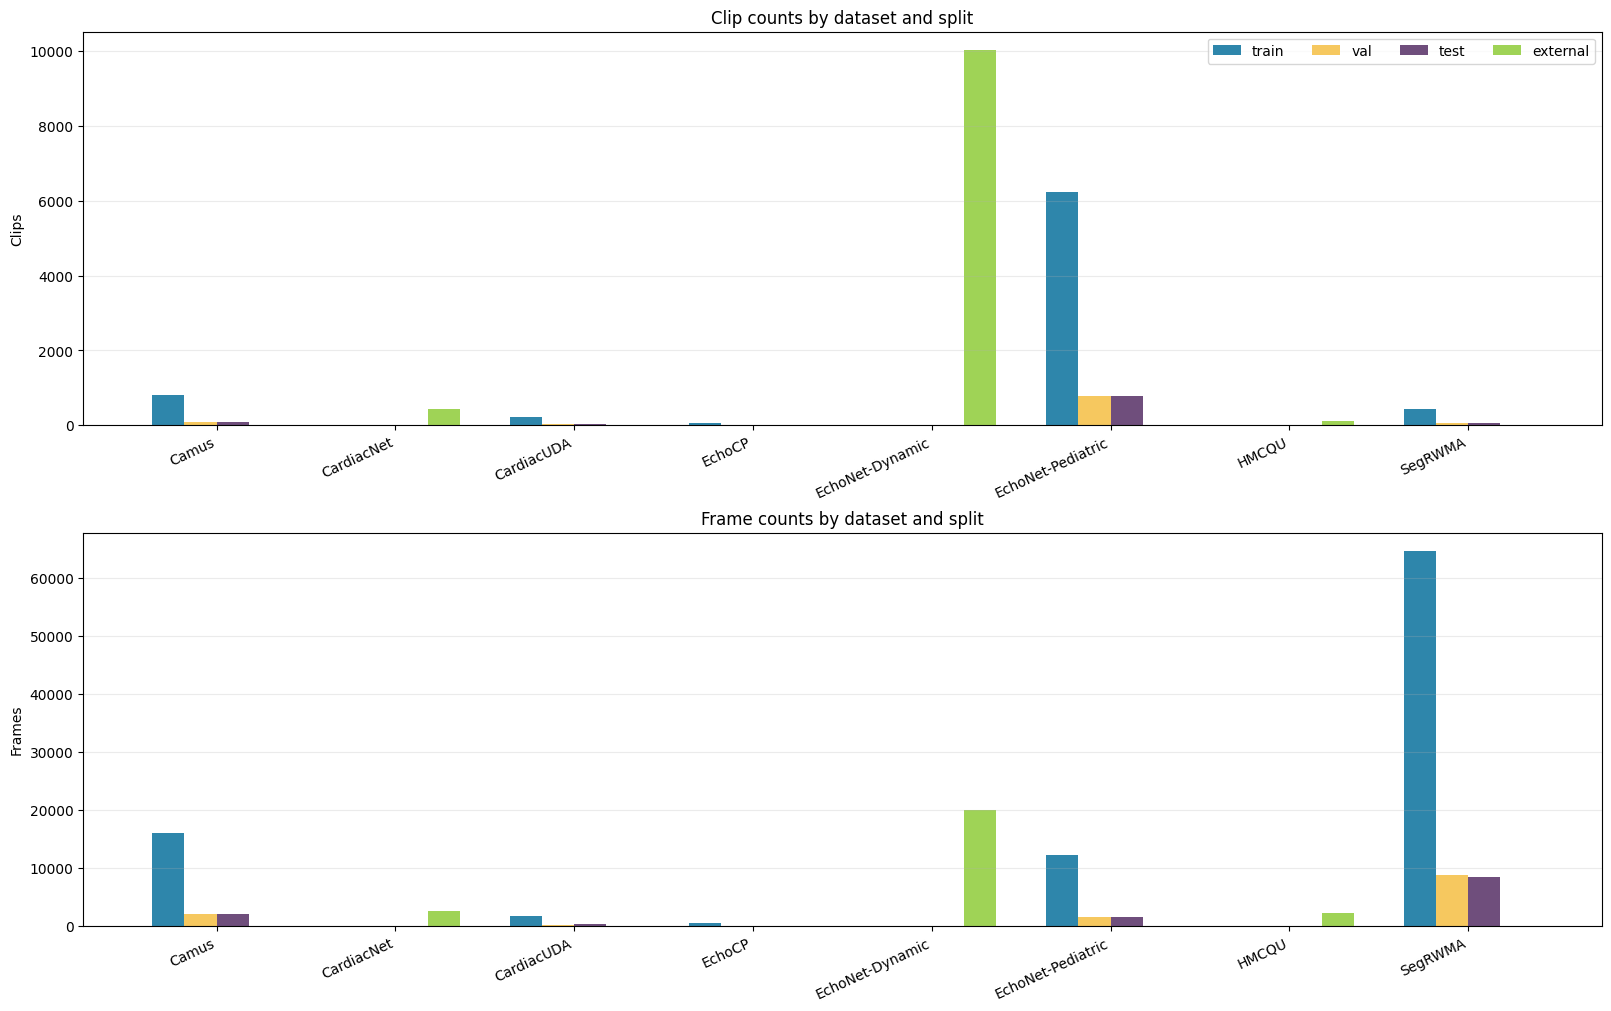

In [107]:
clip_counts = {split: Counter() for split in split_names}
frame_counts = {split: Counter() for split in split_names}

for r in records:
    clip_counts[r["split"]][r["dataset"]] += 1
    frame_counts[r["split"]][r["dataset"]] += r["num_frames"]

x = np.arange(len(dataset_names))
width = 0.18

fig, axes = plt.subplots(2, 1, figsize=(16, 10), constrained_layout=True)

for i, split in enumerate(split_names):
    axes[0].bar(
        x + (i - 1.5) * width,
        [clip_counts[split].get(ds, 0) for ds in dataset_names],
        width=width,
        label=split,
        color=colors[split],
    )

axes[0].set_title("Clip counts by dataset and split")
axes[0].set_ylabel("Clips")
axes[0].set_xticks(x)
axes[0].set_xticklabels(dataset_names, rotation=25, ha="right")
axes[0].legend(ncols=4)
axes[0].grid(axis="y", alpha=0.25)

for i, split in enumerate(split_names):
    axes[1].bar(
        x + (i - 1.5) * width,
        [frame_counts[split].get(ds, 0) for ds in dataset_names],
        width=width,
        label=split,
        color=colors[split],
    )

axes[1].set_title("Frame counts by dataset and split")
axes[1].set_ylabel("Frames")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dataset_names, rotation=25, ha="right")
axes[1].grid(axis="y", alpha=0.25)

plt.show()

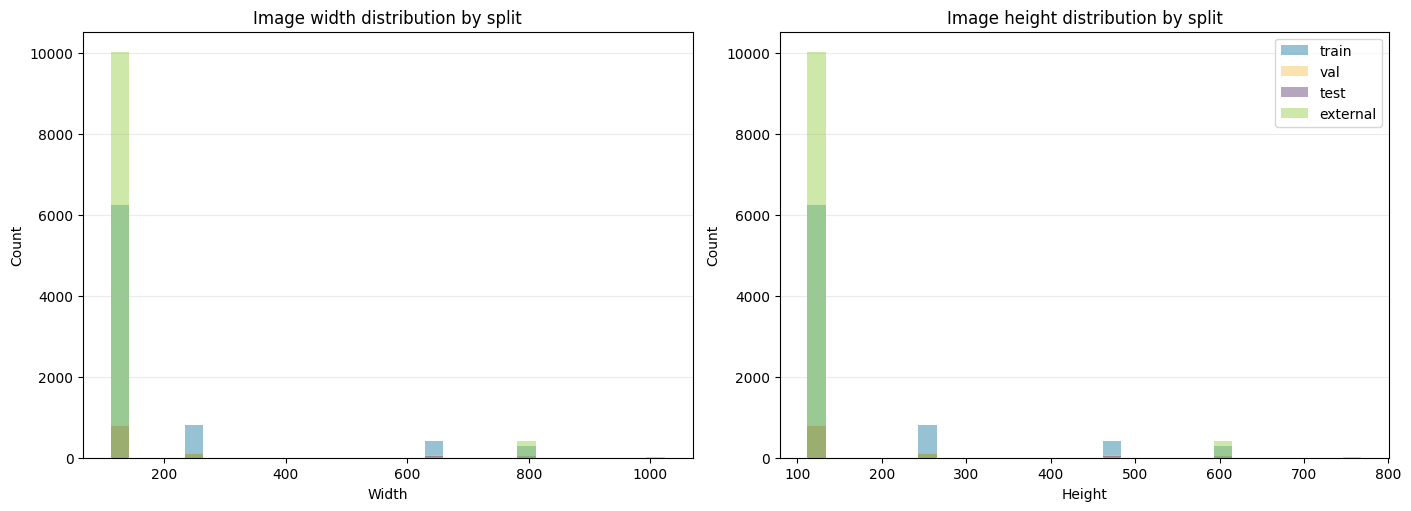

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for split in split_names:
    widths = [r["width"] for r in records if r["split"] == split]
    heights = [r["height"] for r in records if r["split"] == split]
    axes[0].hist(widths, bins=30, alpha=0.5, label=split, color=colors[split])
    axes[1].hist(heights, bins=30, alpha=0.5, label=split, color=colors[split])

axes[0].set_title("Image width distribution by split")
axes[0].set_xlabel("Width")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.25)

axes[1].set_title("Image height distribution by split")
axes[1].set_xlabel("Height")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

plt.show()

## Sample qualitative visualizations

Random converted clips with RGB, label mask, and overlay.

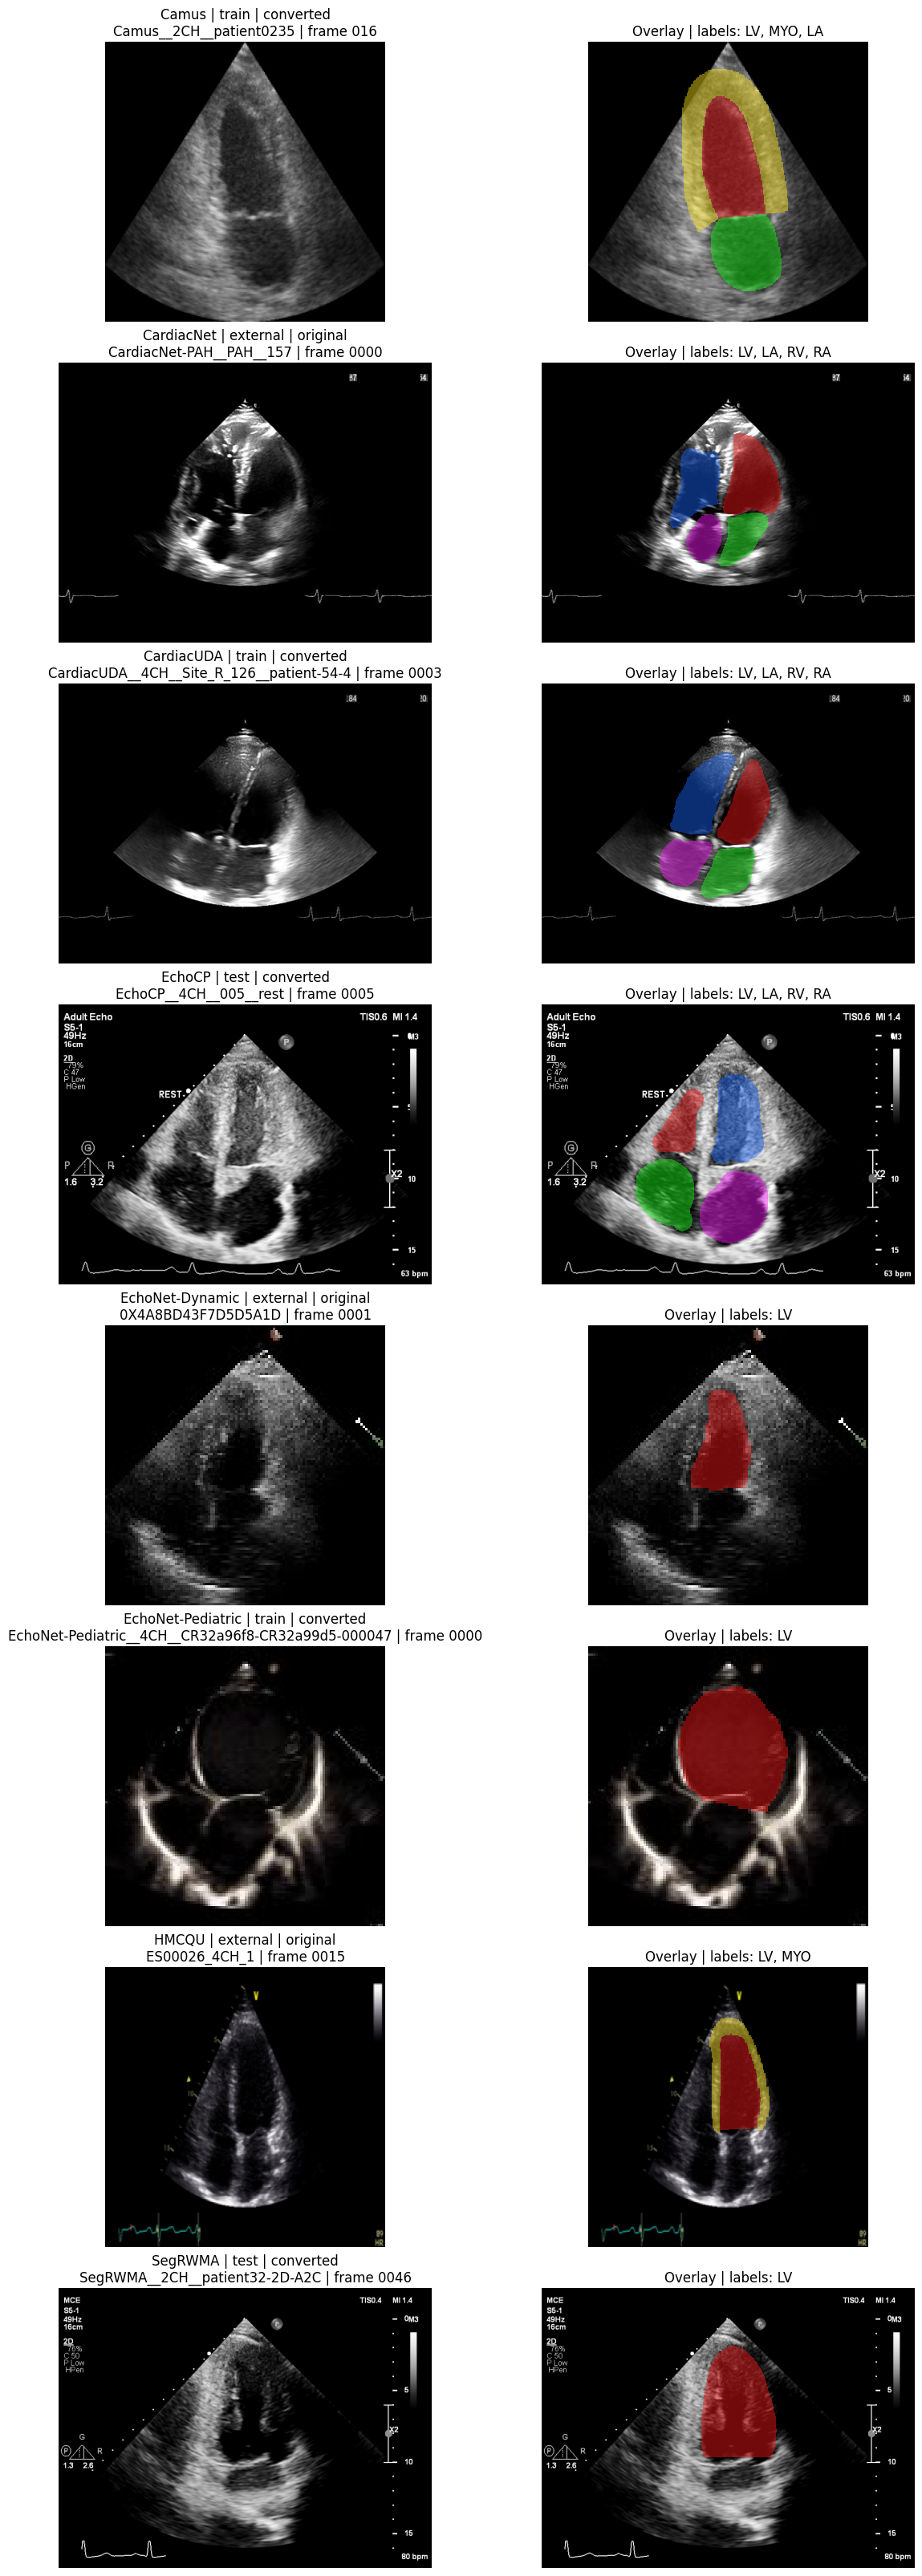

In [109]:
import random
from collections import defaultdict
from pathlib import Path
from PIL import Image
from matplotlib.colors import ListedColormap

converted_root = root / "data" / "echo-ref-vos"
source_root = root / "data" / "Dataset-Echocardiography-MPS-Video"
split_to_dir = {"train": "train", "val": "valid", "test": "test"}
label_names = {0: "BG", 1: "LV", 2: "MYO", 3: "LA", 4: "RV", 5: "RA"}
overlay_cmap = ListedColormap([
    (0.0, 0.0, 0.0, 0.0),
    (1.0, 0.1, 0.1, 0.45),
    (1.0, 0.9, 0.1, 0.45),
    (0.1, 1.0, 0.1, 0.45),
    (0.1, 0.4, 1.0, 0.45),
    (1.0, 0.1, 1.0, 0.45),
])

def resolve_source_path(raw_path):
    raw = str(raw_path)
    cleaned = raw[2:] if raw.startswith("./") else raw
    return (source_root.parent / cleaned).resolve()

videos_by_dataset = defaultdict(list)
for split in ["train", "val", "test"]:
    split_dir = split_to_dir[split]
    meta = json.loads((converted_root / split_dir / "meta.json").read_text())["videos"]
    for video_id in meta:
        dataset = video_id.split("__", 1)[0]
        videos_by_dataset[dataset].append({
            "split": split,
            "source": "converted",
            "video_id": video_id,
            "images_dir": converted_root / split_dir / "JPEGImages" / video_id,
            "masks_dir": converted_root / split_dir / "Annotations" / video_id,
            "image_suffix": ".jpg",
        })

for item in splits["external"]:
    dataset = item["dataset"]
    videos_by_dataset[dataset].append({
        "split": "external",
        "source": "original",
        "video_id": item["clip_id"],
        "images_dir": resolve_source_path(item["images_dir"]),
        "masks_dir": resolve_source_path(item["masks_dir"]),
        "image_suffix": ".png",
    })

selected = []
for dataset in sorted(videos_by_dataset):
    item = random.choice(videos_by_dataset[dataset])
    image_paths = sorted(item["images_dir"].glob(f"*{item['image_suffix']}"))
    frame_candidates = []
    for image_path in image_paths:
        mask_path = item["masks_dir"] / f"{image_path.stem}.png"
        mask_array = np.array(Image.open(mask_path), dtype=np.uint8)
        if np.any(mask_array != 0):
            frame_candidates.append((image_path, mask_array))
    if frame_candidates:
        rep_frame, mask = random.choice(frame_candidates)
    else:
        rep_frame = random.choice(image_paths)
        mask = np.array(Image.open(item["masks_dir"] / f"{rep_frame.stem}.png"), dtype=np.uint8)
    rgb = np.array(Image.open(rep_frame).convert("RGB"))
    labels = [label_names[i] for i in sorted(np.unique(mask).tolist()) if i != 0]
    selected.append((dataset, item["split"], item["source"], item["video_id"], rep_frame.stem, rgb, mask, labels))

fig, axes = plt.subplots(len(selected), 2, figsize=(12, 4 * len(selected)), constrained_layout=True)
if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (dataset, split, source_name, video_id, frame_id, rgb, mask, labels) in enumerate(selected):
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{dataset} | {split} | {source_name}\n{video_id} | frame {frame_id}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(rgb)
    axes[row, 1].imshow(mask, vmin=0, vmax=5, cmap=overlay_cmap, interpolation="nearest")
    axes[row, 1].set_title("Overlay | labels: " + ", ".join(labels))
    axes[row, 1].axis("off")

plt.show()